# Quantum-enhanced Markov chain Monte Carlo

このチュートリアルでは、Qamomile を使って、Quantum-enhanced Markov chain Monte Carlo (QeMCMC) を実装する例を示します。

In [75]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

---
## 背景

### ボルツマン分布のサンプリング

多くの物理・工学的な問題では、ある確率分布 $\pi(\bm{x})$ からサンプル $\bm{x}$ を得ることが重要な計算タスクになります。
代表的な例が、統計力学における**ボルツマン分布**です:
$$
\pi(\bm{x}) = \frac{1}{Z} \exp\bigl(-\beta E(\bm{x})\bigr), \quad Z = \sum_{\bm{x}} \exp\bigl(-\beta E(\bm{x})\bigr).
$$
ここで、$E(\bm{x})$ は状態 $\bm{x}$ のエネルギー、$\beta = 1/T$ は逆温度、$Z$ は分配関数と呼ばれる規格化定数です。
ボルツマン分布は熱平衡状態のスピン配置を記述するだけでなく、組合せ最適化問題に対するサンプリング手法としても広く利用されています。

ボルツマン分布の具体例として、**イジング模型**を考えてみましょう。
イジング模型は、各サイト $i$ にスピン変数 $x_i \in \{-1, +1\}$ が置かれた系で、そのエネルギーは次式で与えられます:
$$
E(\bm{x}) = -\sum_{\langle i, j \rangle} J_{ij} \, x_i x_j - \sum_i h_i \, x_i.
$$
ここで、$J_{ij}$ はスピン間の相互作用、$h_i$ はサイト $i$ にかかる外部磁場です。
状態の総数は $2^n$ と指数的に増えるため、$n$ が大きい場合には分配関数 $Z$ を厳密に計算することは困難です。
そこで、$\pi(\bm{x})$ から直接サンプルを得る手法として、後述する MCMC が利用されます。

まずは、小さなイジング模型について実際にボルツマン分布を可視化してみましょう。
ここでは、1 次元強磁性イジング鎖（$J_{ij} = 1$、$h_i = 0$）を考え、逆温度 $\beta$ を変えながら、エネルギー $E(\bm{x})$ ごとの確率を集計したヒストグラムをプロットします。

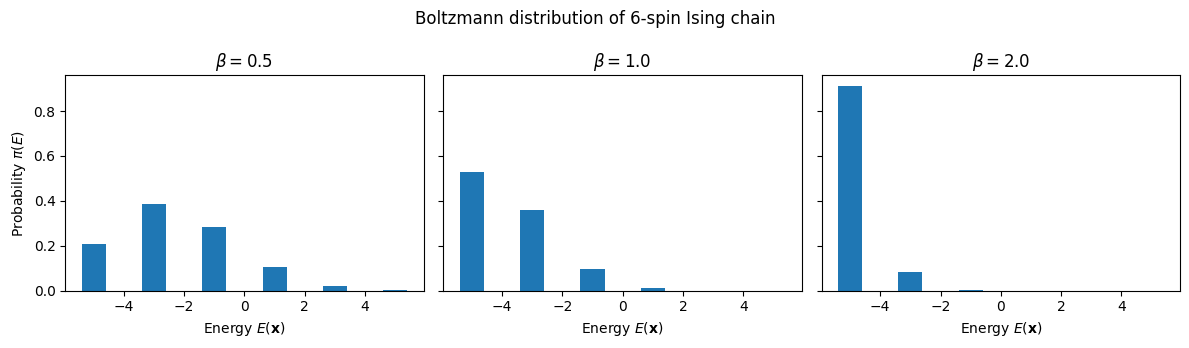

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_spins = 6
J = 1.0

# 1次元強磁性イジング鎖のエネルギー (外部磁場なし)
def ising_energy(state):
    return -J * np.sum(state[:-1] * state[1:])

# 2^n すべての状態を列挙
all_states = np.array(
    [[1 - 2 * ((k >> i) & 1) for i in range(n_spins)] for k in range(2**n_spins)]
)
energies = np.array([ising_energy(s) for s in all_states])

# エネルギーごとにボルツマン分布を集計してヒストグラムとしてプロット
unique_energies = np.unique(energies)
betas = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(betas), figsize=(12, 3.5), sharey=True)

for ax, beta in zip(axes, betas):
    weights = np.exp(-beta * energies)
    probs = weights / weights.sum()
    e_probs = np.array([probs[energies == e].sum() for e in unique_energies])
    ax.bar(unique_energies, e_probs, width=0.8)
    ax.set_xlabel(r"Energy $E(\mathbf{x})$")
    ax.set_title(rf"$\beta = {beta}$")
    
axes[0].set_ylabel(r"Probability $\pi(E)$")
fig.suptitle(f"Boltzmann distribution of {n_spins}-spin Ising chain")
plt.tight_layout()
plt.show()

### マルコフ連鎖モンテカルロ法 (MCMC)

マルコフ連鎖モンテカルロ法 (MCMC) は、確率分布からのサンプリングに使用される一般的な手法です。
MCMC はマルコフ連鎖と呼ばれる確率過程を利用することで、所望の確率分布からのサンプリングを実現します。
ここでは、MCMC の一般的な実装である、Metropolis-Hastings (MH) アルゴリズムを紹介する。

MH アルゴリズムは、ある確率 $Q(\bm{y}|\bm{x})$ に従ってマルコフ連鎖の新たな遷移 $\bm{x} \rightarrow \bm{x}'$ を生成し、この遷移を採択確率
$$
A(\bm{y} | \bm{x}) = \min \left(1, \frac{\pi(\bm{y})}{\pi(\bm{x})} \cdot \frac{Q(\bm{x} | \bm{y})}{Q(\bm{y} | \bm{x})} \right).
$$
に従って採用または棄却するという2つのステップからなる。
この一連の手順により、マルコフ連鎖の時間 $t$ の状態から、次の時間 $t+1$ の状態を生成する。
このマルコフ連鎖は、十分な時間を経たのちに、状態はサンプリングしたい分布 $\pi(\bm{x})$ に従う。
よって、十分に遷移することで、得られるマルコフ連鎖の状態 $\{\bm{x}^{(t)}\}$ を目的のサンプルとして得ることが可能である。

実際に確認してみましょう。
先ほど用意したボルツマン分布を MH 法を使ってサンプリングしてみます。
提案分布にはさまざまなものが使えますが、最もシンプルなものとして、ランダムなスピンを 1 つだけ選んで反転させるというものを利用します。

In [77]:
rng = np.random.default_rng(seed=0)

def local_update(state):
    n = len(state)
    flip_index = rng.integers(0, n)
    new_state = state.copy()
    new_state[flip_index] = int(-1 * state[flip_index])
    return new_state

次に、採択確率に従って、提案された遷移を確率的に処理するステップを実装します。
先ほどの提案分布は、
ボルツマン分布の場合、

In [78]:
def metropolis_hastings(state, new_state, energy_func, beta):
    
    delta_energy = energy_func(new_state) - energy_func(state)

    if delta_energy < 0 or rng.random() < np.exp(-beta * delta_energy):
        return new_state
    else:
        return state

これで MCMC が実装できました。
それでは、MCMCを使ってサンプリングしてみましょう。

In [ ]:
T = 1000 # MCMCのステップ数
beta = 1.0 # 逆温度

sample = np.zeros((T, n_spins))
state = np.ones(n_spins) # 初期状態

for t in range(T):
    # step 1: ローカルな状態更新で新しい状態を提案
    new_state = local_update(state)

    # step 2: メトロポリス・ヘイスティングス法で状態を更新
    state = metropolis_hastings(state, new_state, ising_energy, beta)
    sample[t] = state

得られたサンプル列がボルツマン分布に従っているかを確認しましょう。
得られたサンプルを用いて、ボルツマン分布に関する物理量を推定してみます。
ここでは、スピンの平均磁化:
$$
\langle \mu \rangle = \sum_{\bm{x}} \mu(\bm{x}) m(\bm{x})
$$
を推定します。
磁化は、
$$
m(\bm{x}) = \frac{1}{n} \sum_{i=1}^n x_i
$$
です。
平均磁化は、磁化のボルツマン分布に関する期待値なので、得られたサンプルがボルツマン分布に近いほど良い推定量が得られるはずです。
MCMC の $t$ 番目までのサンプルによる推定量 $\bar{\mu_t}$ をプロットしてみましょう。

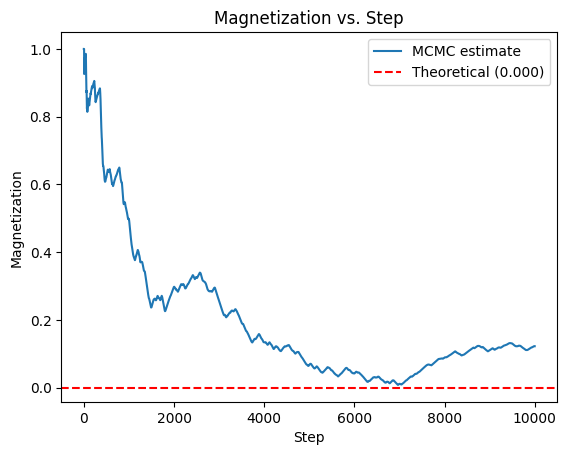

In [80]:
def average_magnetization(sample):
    magnetization = np.mean(sample, axis=1)
    return np.mean(magnetization)

sample_magnetization = np.array([average_magnetization(sample[:i]) for i in range(1, T + 1)])

# 現在の逆温度 beta におけるボルツマン分布から、平均磁化の理論値を計算
weights = np.exp(-beta * energies)
probs = weights / weights.sum()
magnetization_per_state = all_states.mean(axis=1)
theoretical_magnetization = np.sum(probs * magnetization_per_state)

plt.plot(sample_magnetization, label="MCMC estimate")
plt.axhline(
    theoretical_magnetization,
    color="red",
    linestyle="--",
    label=f"Theoretical ({theoretical_magnetization:.3f})",
)
plt.xlabel("Step")
plt.ylabel("Magnetization")
plt.title("Magnetization vs. Step")
plt.legend()
plt.show()

---
## アルゴリズム

Quantum-enhanced MCMC アルゴリズムは、量子回路からのサンプリングを提案分布として利用する MCMC です。
現在の状態 $\bm{x}$ に対して、量子回路 $U$ を作用させ、計算基底で測定することで、新たな状態 $\bm{y}$ を得ます。
このとき、提案分布 $Q(\bm{y}|\bm{x})$ は以下のようになります。
$$
Q(\bm{y}|\bm{x}) = \| \langle \bm{y} | U | \bm{x} \rangle \|^2
$$
この確率を直接計算するのは困難ですが、量子回路が $U = U^\top$ を満たすとき、$Q$ を計算する必要がなくなります。
例えば、イジング模型に対するボルツマン分布のサンプリングのために、QAOA のようなミキサーハミルトニアン $H_M$ とイジングハミルトニアン $H_C$ に対する Trotter 分解の時間発展の量子回路を用いることができます:
$$
U(\gamma, t) = \exp(-i H t)
$$

---
## アルゴリズムの実装

### 1. ハミルトニアンの準備
いよいよ、アルゴリズムを実装していきましょう。
まず、提案分布となる量子回路 $U$ のために、サンプリングしたいイジング模型のハミルトニアン $H_C$ と ミキサーハミルトニアン $H_M$ を準備します。

In [ ]:
from qamomile.observable.hamiltonian import Hamiltonian, X, Z

mixer_hamiltonian = Hamiltonian()
for i in range(n_spins):
    mixer_hamiltonian += X(i)

cost_hamiltonian = Hamiltonian()
for i in range(n_spins - 1):
    cost_hamiltonian += -J * Z(i) * Z(i + 1)

NameError: name 'n' is not defined

### 2. 量子回路の構築

次に、量子回路部分を実装していきましょう。
量子回路は、Trotter分解による時間発展シミュレーションを利用します。
ここでは、`qamomile.circuit.algorithm.trotter` を使い、準備したハミルトニアンに関する量子回路を実装します。

In [ ]:
import qamomile.circuit as qmc
from qamomile.circuit.algorithm.basic import computational_basis_state
from qamomile.circuit.algorithm.trotter import trotterized_time_evolution

@qmc.qkernel
def qemcmc_circuit(
    input: qmc.Vector[qmc.Bit],
    hamiltonian: qmc.Vector[Hamiltonian],
    time: qmc.Float,
    step: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(input.shape[0], name="q")

    # step 1: |input> を計算基底状態として準備
    q = computational_basis_state(q, input)

    # step 2: 2次の Suzuki-Trotter 分解で U = exp(-i H t) を適用
    q = trotterized_time_evolution(q, hamiltonian, 2, time, step)

    # step 3: 計算基底で測定して古典ビット列を返す
    return qmc.measure(q)

### 3. トランスパイル

カーネルをトランスパイルします。
実行する量子回路では、ハミルトニアンの混合係数 $\gamma$ 、シミュレーション時間 $t$ を決定する必要があります。
ここでは、文献 [3] のパラメータ設定を利用し、$\gamma=0.45, t=12, \Delta t = 0.8$ とします。
トランスパイルでは、`time` と `step` はバインドし、`input` はランタイムパラメータとして残します。

In [ ]:
from qamomile.qiskit import QiskitTranspiler

gamma = 0.45
t = 12.0
n_steps = 15
H_s = [(1 - gamma) * mixer_hamiltonian, gamma * cost_hamiltonian]

transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    qemcmc_circuit,
    bindings={"hamiltonian": H_s, "time": t, "step": n_steps},
    parameters=["input"],  # 提案の入力ビット列をランタイムパラメータとする
)

### 4. 量子回路をMCMCに組み込む

これで、量子回路シミュレーションの準備が整いました。
最後に、量子計算のブロックを MCMC に組み込みましょう。
なお、入力および出力はビット列 $\bm{x} = \{0,1\}^n$ であるため、スピン変数 $\bm{s} = \{1, -1\}^n$ との変換も準備しておきます。

In [ ]:
from qiskit_aer import AerSimulator

executor = transpiler.executor(backend=AerSimulator(seed_simulator=7))

def spin_binary_convert(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=int)
    values = np.unique(x)

    if np.any(values == -1) and np.all(np.isin(values, [-1, 1])):
        return (1 - x) // 2                          # s=+1 → 0, s=-1 → 1
    if np.any(values == 0) and np.all(np.isin(values, [0, 1])):
        return 1 - 2 * x                             # b=0 → +1, b=1 → -1
    raise ValueError("Input must be binary in either {-1, 1} or {0, 1}.")

def quantum_update(state: np.ndarray) -> np.ndarray:
    input = list(spin_binary_convert(state))
    
    result = executable.sample(
        executor,
        shots=1,
        bindings={"input": input},
    ).result()

    update_state = result.results[0][0]
    
    return spin_binary_convert(update_state)

---
## 実行例

実装した QeMCMC アルゴリズムを実行してみましょう。
比較のために、前に作った提案分布と一緒にプロットします。

In [ ]:
quantum_sample = np.zeros((T, n_spins))
state = np.ones(n_spins) # 初期状態

for t in range(T):
    # step 1: 量子回路で新しい状態を提案
    new_state = quantum_update(state)

    # step 2: メトロポリス・ヘイスティングス法で状態を更新
    state = metropolis_hastings(state, new_state, ising_energy, beta)
    quantum_sample[t] = state

In [ ]:
quantum_sample_magnetization = np.array([average_magnetization(quantum_sample[:i]) for i in range(1, T + 1)])

plt.plot(sample_magnetization, label="MCMC estimate")
plt.plot(quantum_sample_magnetization, label="QeMCMC estimate")
plt.axhline(
    theoretical_magnetization,
    color="red",
    linestyle="--",
    label=f"Theoretical ({theoretical_magnetization:.3f})",
)
plt.xlabel("Step")
plt.ylabel("Magnetization")
plt.title("Magnetization vs. Step")
plt.legend()
plt.show()

---
## まとめ

本チュートリアルでは、古典的な Metropolis-Hastings 法による MCMC の復習からはじめ、量子回路 $U(\gamma, t) = \exp(-i t H)$ ($H = (1-\gamma) H_M + \gamma H_C$) を提案分布として利用する Quantum-enhanced MCMC (QeMCMC) を Qamomile 上で実装しました。
具体的には、`qamomile.observable` でミキサー/コストハミルトニアンを用意したうえで、`trotterized_time_evolution` による Suzuki-Trotter 時間発展による提案回路を `@qkernel` で構築しました。
最後に、トランスパイルされた excutor を介して量子提案分布を既存の MH ループに組み込み、古典 MCMC と QeMCMC を同一のイジング鎖上で走らせて平均磁化の収束を比較することで、一連の量子古典ハイブリッドループが意図どおり動作することを確認しました。

---
## 参考文献

[1] Layden, D., Mazzola, G., Mishmash, R.V. et al. Quantum-enhanced Markov chain Monte Carlo. Nature 619, 282–287 (2023). https://doi.org/10.1038/s41586-023-06095-4

[2] W. K. Hastings, Monte Carlo sampling methods using Markov chains and their applications, Biometrika, Volume 57, Issue 1, April 1970, Pages 97–109, https://doi.org/10.1093/biomet/57.1.97 

[3] Christmann, Johannes, et al. "From quantum-enhanced to quantum-inspired Monte Carlo." Physical Review A 111.4 (2025): 042615. https://doi.org/10.1103/PhysRevA.111.042615